## Cortico-cerebellar modularity as an architectural inductive bias for efficient temporal learning
Main analysis notebook, used to generate plots and statistics for the paper.

In [14]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import warnings
warnings.filterwarnings("ignore")


In [16]:
from pathlib import Path
PROJECT_ROOT = Path.cwd()

RESULTS_DIR = PROJECT_ROOT / "results"

In [17]:
import os

os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]
import matplotlib as mpl
import matplotlib.pyplot as plt

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# Finding 1: CB-RNN modularity improves curriculum learning efficiency and final performance.

Single Task Curriculum

In [18]:
from analysis.single_task_plotting_utils import _collect_runs, average_and_plot_runs, average_and_plot_runs_multitask

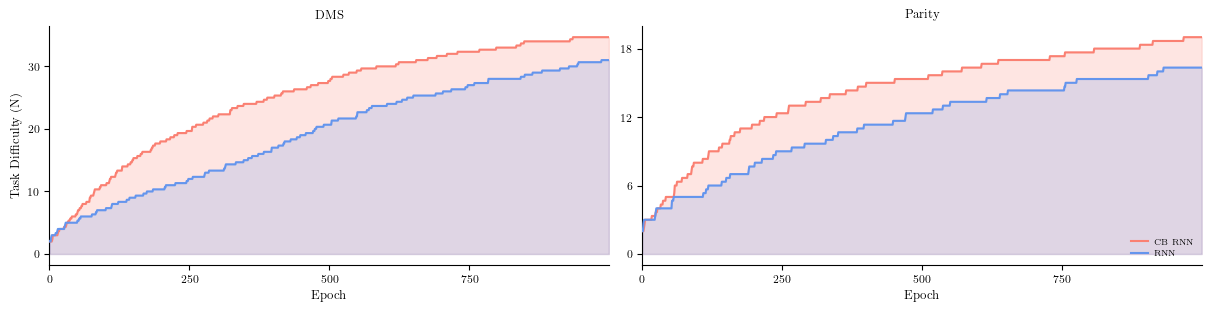

In [19]:
single_task_DMS_DIR = RESULTS_DIR / "single_task/dms_multistyle_repeats"
single_task_PARITY_DIR = RESULTS_DIR / "single_task/parity_multistyle_repeats"

groups = {
    "CB RNN": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_simult_net",
        "color": "salmon"
    },
    "RNN": {
        "pattern": "elman_size_202_noCB",
        "color": "cornflowerblue"
    },
}

task_dirs = {
    "DMS": single_task_DMS_DIR,
    "Parity": single_task_PARITY_DIR,
}

clip_lens = {
    "DMS": 1000,
    "Parity": 1000,
}

clip_Ns = {
    "DMS": None,
    "Parity": None,
}

task_titles = {
    "DMS": "DMS",
    "Parity": "Parity",
}

task_aggs1, fig, axs = average_and_plot_runs_multitask(
    task_dirs=task_dirs,
    groups=groups,
    clip_lens=clip_lens,
    clip_Ns=clip_Ns,
    task_titles=task_titles,
    figure_title="",
    plot_metric2="loss",
    plot_lower_metric=False,
    log_y2=True,
    figsize=(12, 3),
    sharey_top=False,
    shade_auc=True,
    fig_height=0.9,
    shade_sem=False,
    sharey_bottom=True,
    save_path=None
)


Across model scales

DMS | CB GC 64, lr 0.01, CB input | pattern=gc64_RNNlr0.01_CBlr0.01_CBinput_simult_network_ | n=3
DMS | CB GC 128, lr 0.01, CB input | pattern=gc128_RNNlr0.01_CBlr0.01_CBinput_simult_network_ | n=3
DMS | CB GC 256, lr 0.01, CB input | pattern=gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_ | n=3
DMS | CB GC 512, lr 0.01, CB input | pattern=gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_ | n=3
DMS | RNN 128 (match 64), lr 0.01 | pattern=size_128 | n=3
DMS | RNN 160 (match 128), lr 0.01 | pattern=size_160 | n=3
DMS | RNN 202 (match 256), lr 0.01 | pattern=size_202 | n=3
DMS | RNN 272 (match 512), lr 0.01 | pattern=size_272 | n=3
Parity | CB GC 64, lr 0.01, CB input | pattern=gc64_RNNlr0.01_CBlr0.01_CBinput_simult_network_ | n=3
Parity | CB GC 128, lr 0.01, CB input | pattern=gc128_RNNlr0.01_CBlr0.01_CBinput_simult_network_ | n=3
Parity | CB GC 256, lr 0.01, CB input | pattern=gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_ | n=3
Parity | CB GC 512, lr 0.01, CB input | pattern=gc512_RN

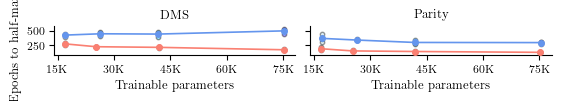

In [24]:
from analysis.scaling import plot_cb_vs_rnn_scaling
CB_groups = {
    "CB GC 64, lr 0.01, CB input": {
        "pattern": "gc64_RNNlr0.01_CBlr0.01_CBinput_simult_network_",
        "color": "lightcoral",
    },
    "CB GC 128, lr 0.01, CB input": {
        "pattern": "gc128_RNNlr0.01_CBlr0.01_CBinput_simult_network_",
        "color": "tomato",
    },
    "CB GC 256, lr 0.01, CB input": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_",
        "color": "orangered",
    },
    "CB GC 512, lr 0.01, CB input": {
        "pattern": "gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_",
        "color": "red",
    },
}

RNN_groups = {
    "RNN 128 (match 64), lr 0.01": {
        "pattern": "size_128",
        "color": "lightblue",
    },
    "RNN 160 (match 128), lr 0.01": {
        "pattern": "size_160",
        "color": "dodgerblue",
    },
    "RNN 202 (match 256), lr 0.01": {
        "pattern": "size_202",
        "color": "deepskyblue",
    },
    "RNN 272 (match 512), lr 0.01": {
        "pattern": "size_272",
        "color": "blue",
    },
}

all_groups = {}
all_groups.update(CB_groups)
all_groups.update(RNN_groups)

fig, axes = plot_cb_vs_rnn_scaling(
    task_configs=[
        {"task_dir": single_task_DMS_DIR,    "groups": all_groups, "task_name": "DMS"},
        {"task_dir": single_task_PARITY_DIR, "groups": all_groups, "task_name": "Parity"},    
        ],
    figsize=None,
    fig_height=0.9,
)


# Finding 2: CB-RNN models retain learning advantage under multi-task and task-switching demands

In [8]:
multitask_dir = RESULTS_DIR / "multi_task"
switch_dir = RESULTS_DIR / "task_switch"

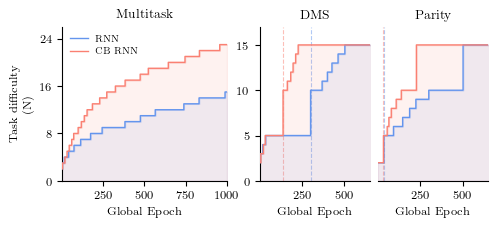

In [9]:
from analysis.plot_multi_switch_combined import plot_multitask_and_switching_combined
fig, axes = plot_multitask_and_switching_combined(
    # multitask
    mt_path_no_cb= multitask_dir / "multitask_mt_elman_size_202_noCB_RNNlr0.01_MULTITASK_network_1/stats_multitask.npy",
    mt_path_cb=multitask_dir / "multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_MULTITASK_network_1/stats_multitask.npy",
    mt_path_cb_affix="CB RNN",
    mt_representative_task="dms",

    # switching
    sw_path_no_cb=switch_dir / "ct_switch_ctswitch_elman_size_202_noCB_RNNlr0.01_CTSWITCH_network_5/stats_continual.npy",
    sw_path_cb=switch_dir / "ct_switch_ctswitch_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_CTSWITCH_network_7/stats_continual.npy",
    sw_affix_cb="CB RNN",
    show_sem=True,
    shade_auc=True,
    annotate_switches=True,
    phase_background="none",
    fig_height=2,
    save_path=None,
)

# Finding 3: CB-RNN efficiency benefit persists under restricted recurrent plasticity

Single task

In [10]:
reservoir_dir = RESULTS_DIR / "reservoir_comparisons"

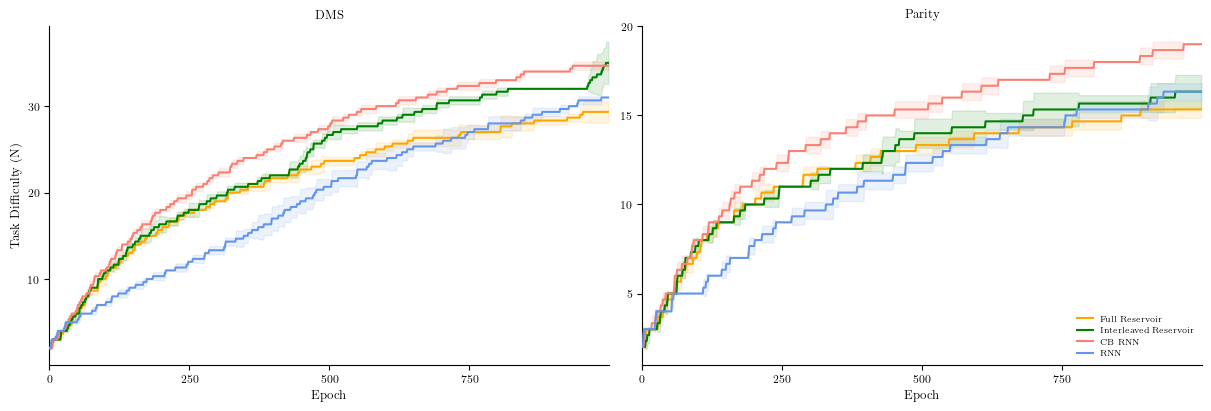

In [11]:
# reservoir plots
dms_path = reservoir_dir / "dms"
parity_path = reservoir_dir / "parity"

groups = {
    "Full Reservoir": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only",
        "color": "orange"
    },
    "Interleaved Reservoir": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_res_n",
        "color": "green"
    },
    "CB RNN": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_simult",
        "color": "salmon"
    },

     "RNN": {
        "pattern": "elman_size_202_noCB",
        "color": "cornflowerblue"
    },
}

task_dirs = {
    "DMS": dms_path,
    "Parity": parity_path,
}

clip_lens = {
    "DMS": None,
    "Parity": None,
}

clip_Ns = {
    "DMS": None,
    "Parity": None,
}

task_titles = {
    "DMS": "DMS",
    "Parity": "Parity"
}

task_aggs, fig, axs = average_and_plot_runs_multitask(
    task_dirs=task_dirs,
    groups=groups,
    clip_lens=clip_lens,
    clip_Ns=clip_Ns,
    task_titles=task_titles,
    plot_metric2="loss", 
    log_y2=True,
    figsize=(12,4),
    sharey_top=False,
    sharey_bottom=True,
    save_path=None
)

Multi-task and task switch

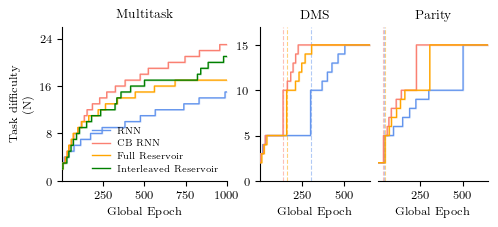

In [12]:
fig, axes = plot_multitask_and_switching_combined(
    # multitask
    mt_path_no_cb= multitask_dir / "multitask_mt_elman_size_202_noCB_RNNlr0.01_MULTITASK_network_1/stats_multitask.npy",
    mt_path_cb=multitask_dir / "multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_MULTITASK_network_1/stats_multitask.npy",
    mt_path_cb_2=multitask_dir / "multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_global_res_MULTITASK_network_1/stats_multitask.npy",
    mt_path_cb_2_affix="Full Reservoir",
    mt_path_cb_3=multitask_dir / "multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_reservoir_MULTITASK_network_1/stats_multitask.npy",
    mt_path_cb_3_affix="Interleaved Reservoir",
    mt_path_cb_affix="CB RNN",
    mt_representative_task="dms",

    # switching
    sw_path_no_cb=switch_dir / "ct_switch_ctswitch_elman_size_202_noCB_RNNlr0.01_CTSWITCH_network_5/stats_continual.npy",
    sw_path_cb=switch_dir / "ct_switch_ctswitch_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_CTSWITCH_network_7/stats_continual.npy",
    sw_affix_cb="CB RNN",
    sw_path_cb_2=switch_dir / "ct_switch_ctswitch_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_global_res_CTSWITCH_network_4/stats_continual.npy",
    sw_affix_cb_2="Full Reservoir",

    show_sem=True,
    shade_auc=False,
    annotate_switches=True,
    phase_background="none",
    fig_height=2,
    save_path=None
)

# Activity analysis

## Finding 4a: Restricted recurrent plasticity shifts representational expansion onto the cerebellar pathway

run PCA

In [17]:
from pathlib import Path
import pandas as pd
import sys
from tasks.tasks_using import make_batch_mtstyle_dms, make_batch_mtstyle_parity
from analysis.activity_analysis import summarize_multi_runs_pca_for_multi_keys

COMMON_KWARGS = dict(
    keys=["hidden", "gc", "pc", "cb_bias"],
    batch_size=64,
    n_batches=10,
    head_idx=0,
    device="cpu",
)

def make_network_paths(base_dir, pattern, networks=(1, 2, 3)):
    base_dir = RESULTS_DIR / base_dir
    return [str(base_dir / pattern.format(i=i)) for i in networks]


RUN_GROUPS = {
    ("dms", "simultaneous"): {
        "paths": make_network_paths(
            "single_task/dms_multistyle_repeats",
            "single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_dms,
    },

    ("dms", "reservoir"): {
        "paths": make_network_paths(
            "reservoir_comparisons/dms",
            "alternating_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_dms,
    },

    ("parity", "simultaneous"): {
        "paths": make_network_paths(
            "single_task/parity_multistyle_repeats",
            "single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_parity,
    },

    ("parity", "reservoir"): {
        "paths": make_network_paths(
            "reservoir_comparisons/parity",
            "alternating_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_parity,
    },
}


results = {}

for (task, regime), cfg in RUN_GROUPS.items():
    print(f"Running PCA summary: task={task}, regime={regime}")

    df = summarize_multi_runs_pca_for_multi_keys(
        run_paths=cfg["paths"],
        batch_fn=cfg["batch_fn"],
        **COMMON_KWARGS,
    )

    df["task"] = task
    df["regime"] = regime

    results[(task, regime)] = df


all_pca_df = pd.concat(results.values(), ignore_index=True)

Running PCA summary: task=dms, regime=simultaneous
Processing run 1/3: single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Processing run 2/3: single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_2
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Processing run 3/3: single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_3
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Runn

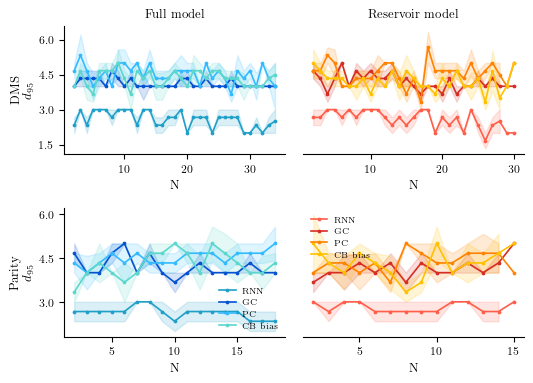

(<Figure size 550x400 with 4 Axes>,
 array([<Axes: title={'center': 'Full model'}, xlabel='N', ylabel='DMS\n $d_{95}$'>,
        <Axes: title={'center': 'Reservoir model'}, xlabel='N'>,
        <Axes: xlabel='N', ylabel='Parity\n $d_{95}$'>, <Axes: xlabel='N'>],
       dtype=object))

In [18]:
from analysis.activity_analysis import plot_two_tasks_full_vs_reservoir_pca_mean_2x2
all_df_cb_dms = results[("dms", "simultaneous")]
all_df_cb_dms_res = results[("dms", "reservoir")]
all_df_cb_parity = results[("parity", "simultaneous")]
all_df_cb_parity_res = results[("parity", "reservoir")]
plot_two_tasks_full_vs_reservoir_pca_mean_2x2(
    df_full_task1=all_df_cb_dms,
    df_res_task1=all_df_cb_dms_res,
    df_full_task2=all_df_cb_parity,
    df_res_task2=all_df_cb_parity_res,
    task1_title="DMS",
    task2_title="Parity",
    fig_height=4,
    metric="d95",
    save_path=None
)

## Finding 4b: Reservoir constraints redistribute longer intrinsic timescales across modules

In [19]:
from pathlib import Path
import pandas as pd

from analysis.timescales import summarize_timescale_multiple_runs, average_across_runs_timescales


NETWORKS = (1, 2, 3)


def make_network_paths(base_dir, pattern, networks=NETWORKS):
    base_dir = RESULTS_DIR / base_dir
    return [str(base_dir / pattern.format(i=i)) for i in networks]


RUN_GROUPS = {
    ("dms", "simultaneous"): make_network_paths(
        "single_task/dms_multistyle_repeats",
        "single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
    ),

    ("dms", "reservoir"): make_network_paths(
        "reservoir_comparisons/dms",
        "alternating_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_{i}",
    ),

    ("parity", "simultaneous"): make_network_paths(
        "single_task/parity_multistyle_repeats",
        "single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
    ),

    ("parity", "reservoir"): make_network_paths(
        "reservoir_comparisons/parity",
        "alternating_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_{i}",
    ),
}

timescale_runs = {}
avg_timescales = {}

for (task, regime), paths in RUN_GROUPS.items():
    print(f"Processing timescales: task={task}, regime={regime}")

    df_runs = summarize_timescale_multiple_runs(paths)
    df_runs["task"] = task
    df_runs["regime"] = regime

    df_avg = average_across_runs_timescales(df_runs)
    df_avg["task"] = task
    df_avg["regime"] = regime

    timescale_runs[(task, regime)] = df_runs
    avg_timescales[(task, regime)] = df_avg

Processing timescales: task=dms, regime=simultaneous
Processing timescales: task=dms, regime=reservoir
Processing timescales: task=parity, regime=simultaneous
Processing timescales: task=parity, regime=reservoir


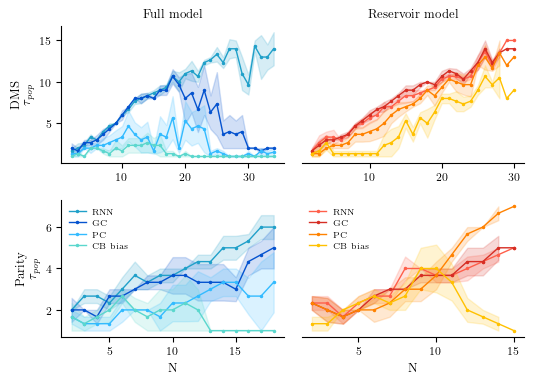

(<Figure size 550x400 with 4 Axes>,
 array([<Axes: title={'center': 'Full model'}, ylabel='DMS\n$\\tau_{pop}$'>,
        <Axes: title={'center': 'Reservoir model'}>,
        <Axes: xlabel='N', ylabel='Parity\n$\\tau_{pop}$'>,
        <Axes: xlabel='N'>], dtype=object))

In [20]:
from analysis.timescales import plot_two_task_full_vs_reservoir_e_folding_2x2
timescale_runs_df = timescale_runs[("dms", "simultaneous")]
avg_timescale_df = avg_timescales[("dms", "simultaneous")]

timescale_runs_res_df = timescale_runs[("dms", "reservoir")]
avg_timescale_res_df = avg_timescales[("dms", "reservoir")]

timescale_runs_par_df = timescale_runs[("parity", "simultaneous")]
avg_timescale_par_df = avg_timescales[("parity", "simultaneous")]

timescale_runs_par_res_df = timescale_runs[("parity", "reservoir")]
avg_timescale_par_res_df = avg_timescales[("parity", "reservoir")]

plot_two_task_full_vs_reservoir_e_folding_2x2(
    avg_df_full_task1=avg_timescale_df,
    avg_df_res_task1=avg_timescale_res_df,
    avg_df_full_task2=avg_timescale_par_df,
    avg_df_res_task2=avg_timescale_par_res_df,
    fig_height=4,
    savepath=None,
    ylim_vals=None,
)

# Finding 5: Post-training ablation reveals functional dependence on cerebellar pathway for structuring recurrent representations

Task accuracy 

In [21]:
from pathlib import Path
import pandas as pd

from analysis.ablation import (
    compare_cb_ablation_many_runs,
    summarize_cb_ablation_many_runs,
    evaluate_rnnonly_many_runs,
    summarize_rnnonly_many_runs,
)

from tasks.tasks_using import make_batch_mtstyle_dms, make_batch_mtstyle_parity


NETWORKS = (1, 2, 3)

COMMON_KWARGS = dict(
    batch_size=64,
    n_batches=20,
    head_idx=0,
    device="cpu",
)


def make_network_paths(base_dir, pattern, networks=NETWORKS):
    base_dir = RESULTS_DIR / base_dir
    return [str(base_dir / pattern.format(i=i)) for i in networks]


RUN_GROUPS = {
    "dms": {
        "batch_fn": make_batch_mtstyle_dms,
        "cb_paths": make_network_paths(
            "reservoir_comparisons/dms",
            "single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "rnn_paths": make_network_paths(
            "single_task/dms_multistyle_repeats",
            "single_dms_elman_size_202_noCB_RNNlr0.01_network_{i}",
        ),
    },

    "parity": {
        "batch_fn": make_batch_mtstyle_parity,
        "cb_paths": make_network_paths(
            "reservoir_comparisons/parity",
            "single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "rnn_paths": make_network_paths(
            "single_task/parity_multistyle_repeats",
            "single_parity_elman_size_202_noCB_RNNlr0.01_network_{i}",
        ),
    },
}

In [26]:
cb_ablation_dfs = {}
cb_ablation_summary_dfs = {}

rnnonly_dfs = {}
rnnonly_summary_dfs = {}

for task, cfg in RUN_GROUPS.items():
    print(f"\nRunning CB ablation analysis: task={task}")

    df_cb = compare_cb_ablation_many_runs(
        run_paths=cfg["cb_paths"],
        batch_fn=cfg["batch_fn"],
        **COMMON_KWARGS,
    )
    df_cb["task"] = task

    df_cb_summary = summarize_cb_ablation_many_runs(df_cb)
    df_cb_summary["task"] = task

    cb_ablation_dfs[task] = df_cb
    cb_ablation_summary_dfs[task] = df_cb_summary

    print(f"Running RNN-only evaluation: task={task}")

    df_rnn = evaluate_rnnonly_many_runs(
        run_paths=cfg["rnn_paths"],
        batch_fn=cfg["batch_fn"],
        **COMMON_KWARGS,
    )
    df_rnn["task"] = task

    df_rnn_summary = summarize_rnnonly_many_runs(df_rnn)
    df_rnn_summary["task"] = task

    rnnonly_dfs[task] = df_rnn
    rnnonly_summary_dfs[task] = df_rnn_summary


Running CB ablation analysis: task=dms
[1/3] single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=2
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=3
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=4
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=5
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=6
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=7
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=8
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=9
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=10
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=11
single_dms_elman_size_64_CB_gc256_

In [27]:
df_ablate_cb = cb_ablation_dfs["dms"]
df_ablate_cb_summary = cb_ablation_summary_dfs["dms"]

df_rnnonly_dms = rnnonly_dfs["dms"]
df_rnnonly_dms_summary = rnnonly_summary_dfs["dms"]

df_ablate_cb_parity = cb_ablation_dfs["parity"]
df_ablate_cb_parity_summary = cb_ablation_summary_dfs["parity"]

df_rnnonly_parity = rnnonly_dfs["parity"]
df_rnnonly_parity_summary = rnnonly_summary_dfs["parity"]

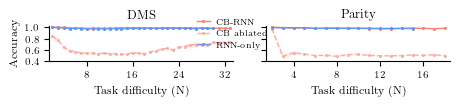

In [28]:
from analysis.ablation import plot_cb_ablation_two_panel
fig, axs = plot_cb_ablation_two_panel(
    df_dms_ablate=df_ablate_cb_summary,
    df_dms_rnn=df_rnnonly_dms_summary,
    df_parity_ablate=df_ablate_cb_parity_summary,
    df_parity_rnn=df_rnnonly_parity_summary,
    fig_height=0.6,
    save_path=None
)

tsne

In [29]:
from analysis.ablation import (
    evaluate_many_runs_over_Ns_with_shared_fixed_batches,
    plot_hidden_class_points_two_tasks_tsne_1row4,
    find_available_Ns
)
dms_run_paths = [
    reservoir_dir/"dms/single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1",
    reservoir_dir/"dms/single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_2",
    reservoir_dir/"dms/single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_3",
]   
par_run_paths = [
    reservoir_dir/"parity/single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1",
    reservoir_dir/"parity/single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_2",
    reservoir_dir/"parity/single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_3",
]
shared_Ns_dms = set(find_available_Ns(dms_run_paths[0]))
for run_path in dms_run_paths[1:]:
    shared_Ns_dms = shared_Ns_dms.intersection(set(find_available_Ns(run_path)))
shared_Ns_dms = sorted(list(shared_Ns_dms))
print(f"Shared Ns across DMS runs: {shared_Ns_dms}")
dms_Ns = [N for N in shared_Ns_dms if N in [4,6,8,12,15,18,24,27,32]]
shared_Ns_par = set(find_available_Ns(par_run_paths[0]))
for run_path in par_run_paths[1:]:
    shared_Ns_par = shared_Ns_par.intersection(set(find_available_Ns(run_path)))
shared_Ns_par = sorted(list(shared_Ns_par))
print(f"Shared Ns across Parity runs: {shared_Ns_par}")
par_Ns = [N for N in shared_Ns_par if N in [5,6,8,10,12,14,15,17]]


df_ablation_dms, all_outputs_dms, fixed_batches_by_N = evaluate_many_runs_over_Ns_with_shared_fixed_batches(
    run_paths=dms_run_paths,
    batch_fn=make_batch_mtstyle_dms,
    Ns=dms_Ns,
    batch_size=64,
    n_batches=10,
    head_idx=0,
    device="cpu",
    return_outputs=True,
)

df_ablation_par, all_outputs_par, fixed_batches_by_N = evaluate_many_runs_over_Ns_with_shared_fixed_batches(
    run_paths=par_run_paths,
    batch_fn=make_batch_mtstyle_parity,
    Ns=par_Ns,
    batch_size=64,
    n_batches=10,
    head_idx=0,
    device="cpu",
    return_outputs=True,
)


Shared Ns across DMS runs: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Shared Ns across Parity runs: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
[1/3] single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=4
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=6
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=8
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=12
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=15
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=18
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=24
single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=27


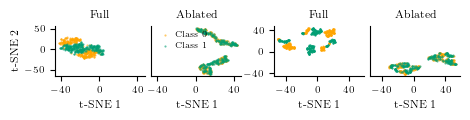

In [30]:
dms_run_id = list(all_outputs_dms.keys())[1]
parity_run_id = list(all_outputs_par.keys())[1]

fig, axs = plot_hidden_class_points_two_tasks_tsne_1row4(
    all_outputs_task1=all_outputs_dms,
    run_id_task1=dms_run_id,
    N_task1=12,

    all_outputs_task2=all_outputs_par,
    run_id_task2=parity_run_id,
    N_task2=6,

    module_key="hidden",
    perplexity=30,
    random_state=0,
    task1_title="DMS",
    task2_title="Parity",
    fig_height=0.95,
    save_path=None,
)

# Supplementary analyses

## Appendix C: GRU-based Controls

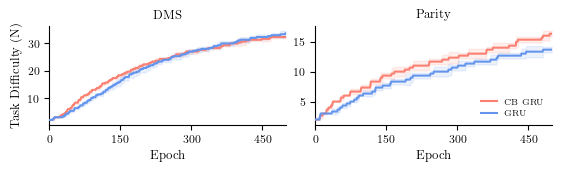

In [31]:
GRU_DMS_DIR = RESULTS_DIR / "GRU_test/dms"
GRU_parity_DIR = RESULTS_DIR / "GRU_test/parity"

groups = {
    "CB GRU": {
        "pattern": "gru_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput",
        "color": "salmon"
    },
    "GRU": {
        "pattern": "gru_size_128_noCB",
        "color": "cornflowerblue"
    },
}

task_dirs = {
    "DMS": GRU_DMS_DIR,
    "Parity": GRU_parity_DIR,
}

clip_lens = {
    "DMS": 500,
    "Parity": 500,
}

clip_Ns = {
    "DMS": None,
    "Parity": None,
}

task_titles = {
    "DMS": "DMS",
    "Parity": "Parity",
}

task_aggs1, fig, axs = average_and_plot_runs_multitask(
    task_dirs=task_dirs,
    groups=groups,
    clip_lens=clip_lens,
    clip_Ns=clip_Ns,
    task_titles=task_titles,
    figure_title="",
    plot_metric2="loss",  
    log_y2=True,
    # figsize=(12, 3),
    sharey_top=False,
    shade_auc=False,
    fig_height=1.6,
    shade_sem=True,
    sharey_bottom=True,
    save_path=None
)


In [32]:
# GRU performance stats
from analysis.performance_analysis import analyse_single_task_groups,analyse_multitask_groups,analyse_switch_groups
CB_runpaths = [
    GRU_DMS_DIR / "single_dms_gru_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_network_1",
    GRU_DMS_DIR / "single_dms_gru_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_network_2",
    GRU_DMS_DIR / "single_dms_gru_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_network_3"
]
rnn_runpaths = [
    GRU_DMS_DIR / "single_dms_gru_size_128_noCB_RNNlr0.01_network_1",
    GRU_DMS_DIR / "single_dms_gru_size_128_noCB_RNNlr0.01_network_2",
    GRU_DMS_DIR / "single_dms_gru_size_128_noCB_RNNlr0.01_network_3"
]


groups = {
    "CB-GRU": CB_runpaths,
    "GRU-only": rnn_runpaths,
}

single = analyse_single_task_groups(
    groups,
    filename="stats.npy",      
    epoch_budget=500,         
)

# display(single["run_metrics"])
display(single["summary"])
print("Global max N:", single["global_max_N"])


,model,n_runs,max_N_mean,max_N_sd,max_N_sem,final_N_mean,final_N_sd,final_N_sem,epochs_to_half_global_max_N_mean,epochs_to_half_global_max_N_sd,epochs_to_half_global_max_N_sem,raw_AUC_mean,raw_AUC_sd,raw_AUC_sem,mean_N_mean,mean_N_sd,mean_N_sem
0,CB-GRU,3,32.333333,0.577350,0.333333,32.333333,0.577350,0.333333,141.666667,6.110101,3.527668,11008.5,263.616672,152.199157,22.051333,0.527793,0.304721
1,GRU-only,3,33.666667,1.154701,0.666667,33.666667,1.154701,0.666667,163.000000,15.099669,8.717798,10699.5,479.913534,277.078208,21.434667,0.960850,0.554747


Global max N: 35.0


In [33]:
# GRU performance stats
CB_runpaths = [
    GRU_parity_DIR / "single_parity_gru_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_network_1",
    GRU_parity_DIR / "single_parity_gru_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_network_2",
    GRU_parity_DIR / "single_parity_gru_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_network_3"
]
rnn_runpaths = [
    GRU_parity_DIR / "single_parity_gru_size_128_noCB_RNNlr0.01_network_1",
    GRU_parity_DIR / "single_parity_gru_size_128_noCB_RNNlr0.01_network_2",
    GRU_parity_DIR / "single_parity_gru_size_128_noCB_RNNlr0.01_network_3"
]


groups = {
    "CB-GRU": CB_runpaths,
    "GRU-only": rnn_runpaths,
}

single = analyse_single_task_groups(
    groups,
    filename="stats.npy",      
    epoch_budget=500,         
)

# display(single["run_metrics"])
display(single["summary"])
print("Global max N:", single["global_max_N"])


,model,n_runs,max_N_mean,max_N_sd,max_N_sem,final_N_mean,final_N_sd,final_N_sem,epochs_to_half_global_max_N_mean,epochs_to_half_global_max_N_sd,epochs_to_half_global_max_N_sem,raw_AUC_mean,raw_AUC_sd,raw_AUC_sem,mean_N_mean,mean_N_sd,mean_N_sem
0,CB-GRU,3,16.333333,0.57735,0.333333,16.333333,0.57735,0.333333,133.000000,14.000000,8.082904,5388.5,227.417567,131.299594,10.795333,0.45511,0.262758
1,GRU-only,3,13.666667,0.57735,0.333333,13.666667,0.57735,0.333333,189.333333,26.388129,15.235193,4601.5,266.633175,153.940735,9.218667,0.53375,0.308161


Global max N: 17.0


## Appendix D: Model-size variation in single-task training

Single Task

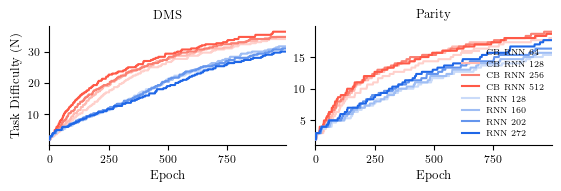

In [34]:
single_task_DMS_DIR = RESULTS_DIR / "single_task/dms_multistyle_repeats"
single_task_PARITY_DIR = RESULTS_DIR / "single_task/parity_multistyle_repeats"

groups = {
    "CB RNN 64": {
        "pattern": "gc64_RNNlr0.01_CBlr0.01_CBinput_simult",
        "color": "#FFD0CB"
    },
    "CB RNN 128": {
        "pattern": "gc128_RNNlr0.01_CBlr0.01_CBinput",
        "color": "#FFB9B1"
    },
    "CB RNN 256": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_simult",
        "color": "salmon"
    },
    "CB RNN 512": {
        "pattern": "gc512_RNNlr0.01_CBlr0.01_CBinput",
        "color": "#FF5947"
    },
    "RNN 128": {
        "pattern": "elman_size_128_noCB",
        "color": "#CADBF9"
    },
    "RNN 160": {
        "pattern": "elman_size_160_noCB",
        "color": "#9EBDF4"
    },
    "RNN 202": {
        "pattern": "elman_size_202_noCB",
        "color": "cornflowerblue"
    },
    "RNN 272": {
        "pattern": "elman_size_272_noCB",
        "color": "#1F67E7"
    },
}

task_dirs = {
    "DMS": single_task_DMS_DIR,
    "Parity": single_task_PARITY_DIR,
}

clip_lens = {
    "DMS": 1000,
    "Parity": 1000,
}

clip_Ns = {
    "DMS": None,
    "Parity": None,
}

task_titles = {
    "DMS": "DMS",
    "Parity": "Parity",
}

task_aggs1, fig, axs = average_and_plot_runs_multitask(
    task_dirs=task_dirs,
    groups=groups,
    clip_lens=clip_lens,
    clip_Ns=clip_Ns,
    task_titles=task_titles,
    figure_title="",
    plot_metric2="loss",  
    log_y2=True,
    # figsize=(12, 3),
    sharey_top=False,
    shade_auc=False,
    fig_height=1.8,
    shade_sem=False,
    sharey_bottom=True,
    save_path=None
)


Expansion vs Non-expansion


DMS
GC64 - RNN128: 4418.8333 ± 1006.1504 SD, n=3
GC256 - RNN202: 5880.1667 ± 612.0744 SD, n=3

Parity
GC64 - RNN128: 2711.0000 ± 523.7242 SD, n=3
GC256 - RNN202: 2872.3333 ± 280.4177 SD, n=3


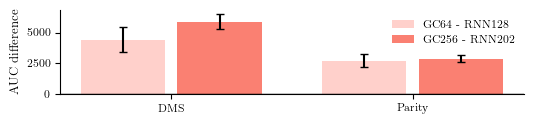

In [35]:

from analysis.single_task_plotting_utils import compute_auc_differences_all_pairs, plot_auc_differences_all_pairs

matched_pairs = {
    "GC64 - RNN128": ("CB RNN 64", "RNN 128"),
    "GC256 - RNN202": ("CB RNN 256", "RNN 202"),
}
df_auc_diffs = compute_auc_differences_all_pairs(
    task_aggs=task_aggs1,
    task_dirs=task_dirs,
    matched_pairs=matched_pairs,
)
fig, ax = plot_auc_differences_all_pairs(
    df_auc_diffs,
    pair_order=[
        "GC64 - RNN128",
        "GC256 - RNN202",
    ],
    figsize=None,
    fig_height=1.4,
    save_path=None,
)


Representational Analyses

In [36]:
from pathlib import Path
import pandas as pd
import sys
from tasks.tasks_using import make_batch_mtstyle_dms, make_batch_mtstyle_parity
from analysis.activity_analysis import summarize_multi_runs_pca_for_multi_keys

COMMON_KWARGS = dict(
    keys=["hidden", "gc", "pc", "cb_bias"],
    batch_size=64,
    n_batches=10,
    head_idx=0,
    device="cpu",
)

def make_network_paths(base_dir, pattern, networks=(1, 2, 3)):
    base_dir = RESULTS_DIR / base_dir
    return [str(base_dir / pattern.format(i=i)) for i in networks]


RUN_GROUPS = {
    ("dms", "normal"): {
        "paths": make_network_paths(
            "single_task/dms_multistyle_repeats",
            "single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_dms,
    },
    ("dms", "large"): {
        "paths": make_network_paths(
            "single_task/dms_multistyle_repeats",
            "single_dms_elman_size_64_CB_gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_dms,
    },
    ("parity", "normal"): {
        "paths": make_network_paths(
            "single_task/parity_multistyle_repeats",
            "single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_parity,
    },
    ("parity", "large"): {
        "paths": make_network_paths(
            "single_task/parity_multistyle_repeats",
            "single_parity_elman_size_64_CB_gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_parity,
    },
}


results = {}

for (task, regime), cfg in RUN_GROUPS.items():
    print(f"Running PCA summary: task={task}, regime={regime}")

    df = summarize_multi_runs_pca_for_multi_keys(
        run_paths=cfg["paths"],
        batch_fn=cfg["batch_fn"],
        **COMMON_KWARGS,
    )

    df["task"] = task
    df["regime"] = regime

    results[(task, regime)] = df


all_pca_df = pd.concat(results.values(), ignore_index=True)

Running PCA summary: task=dms, regime=normal
Processing run 1/3: single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Processing run 2/3: single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_2
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Processing run 3/3: single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_3
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PC

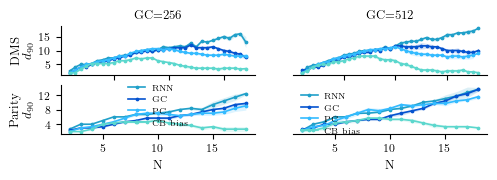

(<Figure size 550x140 with 4 Axes>,
 array([<Axes: title={'center': 'GC=256'}, xlabel='N', ylabel='DMS\n$d_{90}$'>,
        <Axes: title={'center': 'GC=512'}, xlabel='N'>,
        <Axes: xlabel='N', ylabel='Parity\n$d_{90}$'>, <Axes: xlabel='N'>],
       dtype=object))

In [37]:
all_df_cb_dms_large = results[("dms", "large")]
all_df_cb_dms_normal = results[("dms", "normal")]
all_df_cb_parity_normal = results[("parity", "normal")]
all_df_cb_parity_large = results[("parity", "large")]

from analysis.activity_analysis import plot_two_tasks_small_vs_large_pca_mean_2x2

plot_two_tasks_small_vs_large_pca_mean_2x2(
    all_df_cb_dms_normal,
    all_df_cb_dms_large,
    all_df_cb_parity_normal,
    all_df_cb_parity_large,
    task1_title="DMS",
    task2_title="Parity",
    small_title="GC=256",
    large_title="GC=512",
    fig_height=1.4
)

In [38]:
from pathlib import Path
import pandas as pd

from analysis.timescales import summarize_timescale_multiple_runs, average_across_runs_timescales


NETWORKS = (1, 2, 3)


def make_network_paths(base_dir, pattern, networks=NETWORKS):
    base_dir = RESULTS_DIR / base_dir
    return [str(base_dir / pattern.format(i=i)) for i in networks]


RUN_GROUPS = {
    ("dms", "normal"): make_network_paths(
        "single_task/dms_multistyle_repeats",
        "single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
    ),
    ("dms", "large"): make_network_paths(
        "single_task/dms_multistyle_repeats",
        "single_dms_elman_size_64_CB_gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
    ),
    ("parity", "normal"): make_network_paths(
        "single_task/parity_multistyle_repeats",
        "single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
    ),
    ("parity", "large"): make_network_paths(
        "single_task/parity_multistyle_repeats",
        "single_parity_elman_size_64_CB_gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
    ),
}

timescale_runs = {}
avg_timescales = {}

for (task, regime), paths in RUN_GROUPS.items():
    print(f"Processing timescales: task={task}, regime={regime}")

    df_runs = summarize_timescale_multiple_runs(paths)
    df_runs["task"] = task
    df_runs["regime"] = regime

    df_avg = average_across_runs_timescales(df_runs)
    df_avg["task"] = task
    df_avg["regime"] = regime

    timescale_runs[(task, regime)] = df_runs
    avg_timescales[(task, regime)] = df_avg

Processing timescales: task=dms, regime=normal
Processing timescales: task=dms, regime=large
Processing timescales: task=parity, regime=normal
Processing timescales: task=parity, regime=large


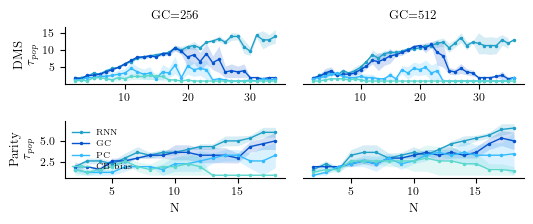

In [39]:
from analysis.timescales import plot_two_task_small_vs_large_e_folding_2x2, average_across_runs_timescales
average_dms_normal = average_across_runs_timescales(timescale_runs[("dms", "normal")])
average_dms_large = average_across_runs_timescales(timescale_runs[("dms", "large")])
average_parity_normal = average_across_runs_timescales(timescale_runs[("parity", "normal")])
average_parity_large = average_across_runs_timescales(timescale_runs[("parity", "large")])
fig, axs = plot_two_task_small_vs_large_e_folding_2x2(
    avg_df_dms_small=average_dms_normal,
    avg_df_dms_large=average_dms_large,
    avg_df_parity_small=average_parity_normal,
    avg_df_parity_large=average_parity_large,
    small_title="GC=256",
    large_title="GC=512",
    modules=("hidden", "gc", "pc", "cb_bias"),
    show_sem=True,
    fig_height=2.4,
    savepath=None,
)

## Appendix E: Cerebellar Input Controls

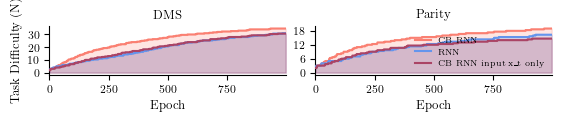

In [40]:
dms_dir = RESULTS_DIR / "single_task/dms_multistyle_repeats"

parity_dir = RESULTS_DIR / "single_task/parity_multistyle_repeats"

groups = {
    "CB RNN": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_simult",
        "color": "salmon"
    },
    "RNN": {
        "pattern": "elman_size_202_noCB",
        "color": "cornflowerblue"
    },
    "CB RNN input x_t only": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_noH",
        "color": "#AA4465"
    },
}

task_dirs = {
    "DMS": dms_dir,
    "Parity": parity_dir,
}

clip_lens = {
    "DMS": 1000,
    "Parity": 1000,
}

clip_Ns = {
    "DMS": None,
    "Parity": None,
}

task_titles = {
    "DMS": "DMS",
    "Parity": "Parity",
}

task_aggs1, fig, axs = average_and_plot_runs_multitask(
    task_dirs=task_dirs,
    groups=groups,
    clip_lens=clip_lens,
    clip_Ns=clip_Ns,
    task_titles=task_titles,
    figure_title="",
    plot_metric2="loss",   # or "acc"
    log_y2=True,
    # figsize=(12, 3),
    sharey_top=False,
    shade_auc=True,
    fig_height=1.1,
    shade_sem=False,
    sharey_bottom=True,
)


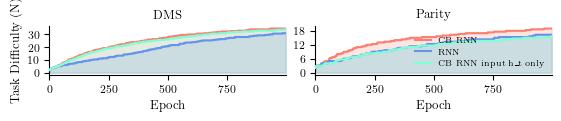

In [41]:
groups = {
    "CB RNN": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_simult",
        "color": "salmon"
    },
    "RNN": {
        "pattern": "elman_size_202_noCB",
        "color": "cornflowerblue"
    },
    "CB RNN input h_t only": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_network",
        "color": "aquamarine"
    },
}

task_dirs = {
    "DMS": dms_dir,
    "Parity": parity_dir,
}

clip_lens = {
    "DMS": 1000,
    "Parity": 1000,
}

clip_Ns = {
    "DMS": None,
    "Parity": None,
}

task_titles = {
    "DMS": "DMS",
    "Parity": "Parity",
}

task_aggs1, fig, axs = average_and_plot_runs_multitask(
    task_dirs=task_dirs,
    groups=groups,
    clip_lens=clip_lens,
    clip_Ns=clip_Ns,
    task_titles=task_titles,
    figure_title="",
    plot_metric2="loss",   # or "acc"
    log_y2=True,
    # figsize=(12, 3),
    sharey_top=False,
    shade_auc=True,
    fig_height=1.1,
    shade_sem=False,
    sharey_bottom=True,
)


## Appendix H: Cerebellar ablation controls

Class separability quantification

In [42]:
from analysis.ablation import decode_auc_over_runs_many_Ns, summarise_decode_across_runs_over_Ns, print_auc_for_N

Ns_dms = [12]
Ns_par = [6]
df_decode_dms_over_Ns = decode_auc_over_runs_many_Ns(
    all_outputs=all_outputs_dms,
    Ns=Ns_dms,
    module_key="hidden",
    conditions=("full", "ablated"),
    cv=5,
    random_state=0,
)

summary_dms_over_Ns = summarise_decode_across_runs_over_Ns(
    df_decode_dms_over_Ns
)

df_decode_parity_over_Ns = decode_auc_over_runs_many_Ns(
    all_outputs=all_outputs_par,
    Ns=Ns_par,
    module_key="hidden",
    conditions=("full", "ablated"),
    cv=5,
    random_state=0,
)

summary_parity_over_Ns = summarise_decode_across_runs_over_Ns(
    df_decode_parity_over_Ns
)

print_auc_for_N(summary_dms_over_Ns, "DMS", 12)
print_auc_for_N(summary_parity_over_Ns, "PAR", 6)


task=DMS | full | N=12 | hidden: ROC-AUC = 0.999 ± 0.000 SD across 3 runs
task=DMS | ablated | N=12 | hidden: ROC-AUC = 0.605 ± 0.009 SD across 3 runs
task=PAR | full | N=6 | hidden: ROC-AUC = 0.998 ± 0.003 SD across 3 runs
task=PAR | ablated | N=6 | hidden: ROC-AUC = 0.685 ± 0.081 SD across 3 runs


Readout retraining during ablation

In [43]:
from pathlib import Path
from tasks.tasks_using import make_batch_mtstyle_dms, make_batch_mtstyle_parity

from analysis.readout_ablation import (
    run_cb_disabled_readout_recovery_across_multiple_runs,
    summarize_cb_disabled_readout_recovery_across_runs,
    plot_cb_disabled_readout_recovery,
)


def make_network_paths(base_dir, pattern, networks=(1, 2, 3)):
    base_dir = RESULTS_DIR / base_dir
    return [str(base_dir / pattern.format(i=i)) for i in networks]

cb_dms_paths = make_network_paths(
    "reservoir_comparisons/dms",
    "single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
)

df_recovery_dms = run_cb_disabled_readout_recovery_across_multiple_runs(
    cb_run_paths=cb_dms_paths,
    batch_fn=make_batch_mtstyle_dms,
    batch_size=64,
    n_train_steps=100,
    lr=1e-2,
    head_idx=0,
    device="cpu",
    eval_batches=50,
)

summary_recovery_dms = summarize_cb_disabled_readout_recovery_across_runs(
    df_recovery_dms
)



[1/3] single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1

===== single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=2 =====
step    0 | loss=0.5376 | acc=0.9844
step   50 | loss=0.5308 | acc=1.0000

===== single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=3 =====
step    0 | loss=0.5108 | acc=0.8594
step   50 | loss=0.5372 | acc=0.7656

===== single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=4 =====
step    0 | loss=0.6039 | acc=0.6094
step   50 | loss=0.5161 | acc=0.7656

===== single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=5 =====
step    0 | loss=0.6107 | acc=0.7500
step   50 | loss=0.5517 | acc=0.7500

===== single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=6 =====
step    0 | loss=0.6178 | acc=0.6562
step   50 | loss=0.6246 | acc=0.5938

===== single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_

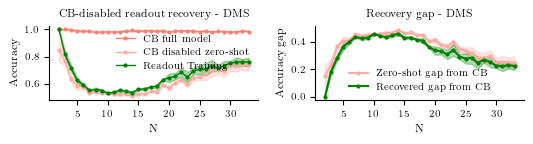

(<Figure size 550x160 with 2 Axes>,
 array([<Axes: title={'center': 'CB-disabled readout recovery - DMS'}, xlabel='N', ylabel='Accuracy'>,
        <Axes: title={'center': 'Recovery gap - DMS'}, xlabel='N', ylabel='Accuracy gap'>],
       dtype=object))

In [44]:
plot_cb_disabled_readout_recovery(
    summary_recovery_dms,
    task_title="DMS",
    fig_size=None,
    fig_height=1.6,
    save_path=None
)

In [45]:
cb_parity_paths = make_network_paths(
    "reservoir_comparisons/parity",
    "single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
)

df_recovery_parity = run_cb_disabled_readout_recovery_across_multiple_runs(
    cb_run_paths=cb_parity_paths,
    batch_fn=make_batch_mtstyle_parity,
    batch_size=64,
    n_train_steps=100,
    lr=1e-2,
    head_idx=0,
    device="cpu",
    eval_batches=50,
)

summary_recovery_parity = summarize_cb_disabled_readout_recovery_across_runs(
    df_recovery_parity
)



[1/3] single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1

===== single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=2 =====
step    0 | loss=0.6419 | acc=0.9844
step   50 | loss=0.6291 | acc=0.8125

===== single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=3 =====
step    0 | loss=0.6352 | acc=0.5938
step   50 | loss=0.6421 | acc=0.6406

===== single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=4 =====
step    0 | loss=0.9563 | acc=0.5625
step   50 | loss=0.8503 | acc=0.3906

===== single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=5 =====
step    0 | loss=2.3181 | acc=0.5625
step   50 | loss=0.7310 | acc=0.3594

===== single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1 | N=6 =====
step    0 | loss=2.5280 | acc=0.5781
step   50 | loss=0.7526 | acc=0.5469

===== single_parity_elman_size_64_CB_gc25

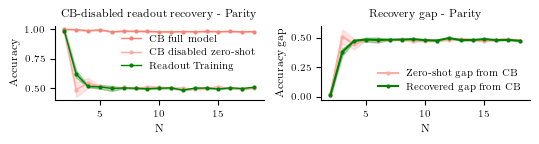

(<Figure size 550x160 with 2 Axes>,
 array([<Axes: title={'center': 'CB-disabled readout recovery - Parity'}, xlabel='N', ylabel='Accuracy'>,
        <Axes: title={'center': 'Recovery gap - Parity'}, xlabel='N', ylabel='Accuracy gap'>],
       dtype=object))

In [46]:
plot_cb_disabled_readout_recovery(
    summary_recovery_parity,
    task_title="Parity",
    fig_size=None,
    fig_height=1.6,
    save_path=None
)

## Appendix I: Performance metrics across all models and tasks

In [47]:
from analysis.performance_analysis import analyse_single_task_groups,analyse_multitask_groups,analyse_switch_groups

### single task

In [48]:

CB_runpaths = [
    reservoir_dir / "dms/single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1",
    reservoir_dir / "dms/single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_2",
    reservoir_dir / "dms/single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_3"
]
rnn_runpaths = [
    reservoir_dir / "dms/single_dms_elman_size_202_noCB_RNNlr0.01_network_1",
    reservoir_dir / "dms/single_dms_elman_size_202_noCB_RNNlr0.01_network_2",
    reservoir_dir / "dms/single_dms_elman_size_202_noCB_RNNlr0.01_network_3"
]
CB_runpaths_fullres = [
    reservoir_dir / "dms/alternating_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_1",
    reservoir_dir / "dms/alternating_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_2",
    reservoir_dir / "dms/alternating_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_3"
]
CB_runpaths_intres = [
    reservoir_dir / "dms/alternating_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_res_network_1",
    reservoir_dir / "dms/alternating_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_res_network_2",
    reservoir_dir / "dms/alternating_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_res_network_3"
]

groups = {
    "CB-RNN": CB_runpaths,
    "RNN-only": rnn_runpaths,
    "Full reservoir": CB_runpaths_fullres,
    "Interleaved reservoir": CB_runpaths_intres,
}

single = analyse_single_task_groups(
    groups,
    filename="stats.npy",      
    epoch_budget=1000,         
)

# display(single["run_metrics"])
display(single["summary"])
print("Global max N:", single["global_max_N"])


,model,n_runs,max_N_mean,max_N_sd,max_N_sem,final_N_mean,final_N_sd,final_N_sem,epochs_to_half_global_max_N_mean,epochs_to_half_global_max_N_sd,epochs_to_half_global_max_N_sem,raw_AUC_mean,raw_AUC_sd,raw_AUC_sem,mean_N_mean,mean_N_sd,mean_N_sem
0,CB-RNN,3,34.666667,0.577350,0.333333,34.666667,0.577350,0.333333,217.000000,7.000000,4.041452,25162.333333,203.314002,117.383394,25.180667,0.203584,0.117539
1,Full reservoir,3,29.333333,1.527525,0.881917,29.333333,1.527525,0.881917,288.333333,7.505553,4.333333,21303.333333,507.883927,293.226922,21.340340,0.509132,0.293947
2,Interleaved reservoir,3,35.000000,3.000000,1.732051,35.000000,3.000000,1.732051,269.000000,19.519221,11.269428,23382.833333,236.471105,136.526656,23.424758,0.236881,0.136763
3,RNN-only,3,31.000000,0.000000,0.000000,31.000000,0.000000,0.000000,443.000000,39.509493,22.810816,19282.166667,757.208250,437.174387,19.298667,0.757208,0.437174


Global max N: 38.0


In [49]:
CB_runpaths = [
    reservoir_dir / "parity/single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1",
    reservoir_dir / "parity/single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_2",
    reservoir_dir / "parity/single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_3"
]
rnn_runpaths = [
    reservoir_dir / "parity/single_parity_elman_size_202_noCB_RNNlr0.01_network_1",
    reservoir_dir / "parity/single_parity_elman_size_202_noCB_RNNlr0.01_network_2",
    reservoir_dir / "parity/single_parity_elman_size_202_noCB_RNNlr0.01_network_3"
]
CB_runpaths_fullres = [
    reservoir_dir / "parity/alternating_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_1",
    reservoir_dir / "parity/alternating_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_2",
    reservoir_dir / "parity/alternating_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_cb_only_network_3"
]
CB_runpaths_intres = [
    reservoir_dir / "parity/alternating_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_res_network_1",
    reservoir_dir / "parity/alternating_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_res_network_2",
    reservoir_dir / "parity/alternating_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_res_network_3"
]

groups = {
    "CB-RNN": CB_runpaths,
    "RNN-only": rnn_runpaths,
    "Full reservoir": CB_runpaths_fullres,
    "Interleaved reservoir": CB_runpaths_intres,
}

single = analyse_single_task_groups(
    groups,
    filename="stats.npy",      
    epoch_budget=1000,        
)

# display(single["run_metrics"])
display(single["summary"])
print("Global max N:", single["global_max_N"])


,model,n_runs,max_N_mean,max_N_sd,max_N_sem,final_N_mean,final_N_sd,final_N_sem,epochs_to_half_global_max_N_mean,epochs_to_half_global_max_N_sd,epochs_to_half_global_max_N_sem,raw_AUC_mean,raw_AUC_sd,raw_AUC_sem,mean_N_mean,mean_N_sd,mean_N_sem
0,CB-RNN,3,19.000000,0.000000,0.000000,19.000000,0.000000,0.000000,146.333333,9.712535,5.607535,14330.166667,213.003130,122.977414,14.340667,0.213003,0.122977
1,Full reservoir,3,15.333333,0.577350,0.333333,15.333333,0.577350,0.333333,170.333333,9.237604,5.333333,12161.000000,267.174568,154.253309,12.181849,0.267727,0.154572
2,Interleaved reservoir,3,16.333333,1.154701,0.666667,16.333333,1.154701,0.666667,175.333333,10.016653,5.783117,12527.500000,534.221864,308.433137,12.549216,0.535329,0.309072
3,RNN-only,3,16.333333,0.577350,0.333333,16.333333,0.577350,0.333333,300.333333,37.872593,21.865752,11457.833333,404.143023,233.332083,11.467000,0.404427,0.233496


Global max N: 19.0


### multitask

In [50]:
CB_runpaths = [
    multitask_dir / "multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_MULTITASK_network_1",
    multitask_dir / "multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_MULTITASK_network_2",
    multitask_dir / "multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_MULTITASK_network_3"
]
rnn_runpaths = [
    multitask_dir / "multitask_mt_elman_size_202_noCB_RNNlr0.01_MULTITASK_network_1",
    multitask_dir / "multitask_mt_elman_size_202_noCB_RNNlr0.01_MULTITASK_network_2",
    multitask_dir / "multitask_mt_elman_size_202_noCB_RNNlr0.01_MULTITASK_network_3"
]
CB_runpaths_fullres = [
    multitask_dir / "multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_global_res_MULTITASK_network_1",
    multitask_dir / "multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_global_res_MULTITASK_network_2",
    multitask_dir / "multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_global_res_MULTITASK_network_3"
]
CB_runpaths_intres = [
    multitask_dir / "multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_reservoir_MULTITASK_network_1",
    multitask_dir / "multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_reservoir_MULTITASK_network_2",
    multitask_dir / "multitask_mt_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_interleaved_reservoir_MULTITASK_network_3"
]

groups = {
    "CB-RNN": CB_runpaths,
    "RNN-only": rnn_runpaths,
    "Full reservoir": CB_runpaths_fullres,
    "Interleaved reservoir": CB_runpaths_intres,
}

multi = analyse_multitask_groups(
    groups,
    filename="stats_multitask.npy",
    task_keys=("N_dms",),      
    epoch_budget=1000,
)

# display(multi["run_metrics"])
display(multi["summary"])
print("Global max N:", multi["global_max_N"])

,model,n_runs,mean_max_N_mean,mean_max_N_sd,mean_max_N_sem,mean_final_N_mean,mean_final_N_sd,mean_final_N_sem,mean_epochs_to_half_global_max_N_mean,mean_epochs_to_half_global_max_N_sd,mean_epochs_to_half_global_max_N_sem,mean_AUC_mean,mean_AUC_sd,mean_AUC_sem,sum_AUC_mean,sum_AUC_sd,sum_AUC_sem,mean_N_mean,mean_N_sd,mean_N_sem
0,CB-RNN,3,22.333333,0.577350,0.333333,22.333333,0.577350,0.333333,157.0,7.937254,4.582576,16589.500000,132.466033,76.479300,16589.500000,132.466033,76.479300,16.601667,0.132644,0.076582
1,Full reservoir,3,18.000000,1.732051,1.000000,18.000000,1.732051,1.000000,238.0,35.679126,20.599353,13598.666667,596.894533,344.617219,13598.666667,596.894533,344.617219,13.608667,0.597416,0.344918
2,Interleaved reservoir,3,18.333333,2.309401,1.333333,18.333333,2.309401,1.333333,221.0,18.027756,10.408330,14232.166667,315.214742,181.989316,14232.166667,315.214742,181.989316,14.242333,0.316282,0.182606
3,RNN-only,3,16.666667,1.527525,0.881917,16.666667,1.527525,0.881917,539.0,28.053520,16.196707,10939.333333,511.385944,295.248812,10939.333333,511.385944,295.248812,10.948667,0.512095,0.295658


Global max N: 23.0


### task switching

In [51]:
CB_runpaths = [
    switch_dir / "ct_switch_ctswitch_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_CTSWITCH_network_7",
    switch_dir / "ct_switch_ctswitch_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_CTSWITCH_network_8",
    switch_dir / "ct_switch_ctswitch_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_CTSWITCH_network_9"
]
rnn_runpaths = [
    switch_dir / "ct_switch_ctswitch_elman_size_202_noCB_RNNlr0.01_CTSWITCH_network_5",
    switch_dir / "ct_switch_ctswitch_elman_size_202_noCB_RNNlr0.01_CTSWITCH_network_6",
    switch_dir / "ct_switch_ctswitch_elman_size_202_noCB_RNNlr0.01_CTSWITCH_network_7"
]
CB_runpaths_fullres = [
    switch_dir / "ct_switch_ctswitch_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_global_res_CTSWITCH_network_4",
    switch_dir / "ct_switch_ctswitch_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_global_res_CTSWITCH_network_5",
    switch_dir / "ct_switch_ctswitch_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_global_res_CTSWITCH_network_6"
]

groups = {
    "CB-RNN": CB_runpaths,
    "RNN-only": rnn_runpaths,
    "Full reservoir": CB_runpaths_fullres,
}

switch = analyse_switch_groups(
    groups,
    filename="stats_continual.npy",
    tasks=("dms", "parity"),
    first_task="dms",
    second_task="parity",
    max_global_epochs=650,
)

# display(switch["run_metrics"])
# display(switch["adaptation_per_run"])
display(switch["summary"])
print("Global max N:", switch["global_max_N"])

,model,n_runs_x,mean_line_max_N_mean,mean_line_max_N_sd,mean_line_max_N_sem,mean_line_final_N_mean,mean_line_final_N_sd,mean_line_final_N_sem,mean_line_AUC_mean,mean_line_AUC_sd,...,n_runs_y,adaptation_speed_epochs_mean,adaptation_speed_epochs_sd,adaptation_speed_epochs_sem,n_successful_switch_phases_mean,n_successful_switch_phases_sd,n_successful_switch_phases_sem,mean_N_gained_mean,mean_N_gained_sd,mean_N_gained_sem
0,CB-RNN,3,12.500000,0.000000,0.000000,12.500000,0.000000,0.000000,5644.083333,13.269640,...,3,31.000000,6.062178,3.500000,2.0,0.0,0.0,4.0,0.0,0.0
1,Full reservoir,3,12.333333,0.288675,0.166667,12.333333,0.288675,0.166667,4983.833333,134.227031,...,3,40.333333,2.309401,1.333333,2.0,0.0,0.0,4.0,0.0,0.0
2,RNN-only,3,9.500000,0.000000,0.000000,9.500000,0.000000,0.000000,3186.916667,83.392646,...,3,59.666667,10.598742,6.119187,1.0,0.0,0.0,2.0,0.0,0.0


Global max N: 15.0


That's all for now!